# 1. Initial Setup
Import the participant data. We will explore this before diving into the EEG Data


In [1]:
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt


tsv_file = r"E:\neuro_data\ds004796\participants.tsv"

df = pd.read_csv(tsv_file, sep='\t')



# 2. Inspect and Clean the Data
Only 70 of the participants completed eeg sessions. The rest will need to be dropped during the EEG analysis

In [2]:
df.info()
df.head()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 87 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            192 non-null    object 
 1   second_phase              192 non-null    int64  
 2   session_order             70 non-null     float64
 3   APOE_rs429358             192 non-null    object 
 4   APOE_rs7412               192 non-null    object 
 5   APOE_haplotype            192 non-null    object 
 6   PICALM_rs3851179          192 non-null    object 
 7   age                       192 non-null    int64  
 8   sex                       192 non-null    int64  
 9   education                 174 non-null    float64
 10  learning_deficits         175 non-null    object 
 11  BMI                       192 non-null    float64
 12  allergies                 73 non-null     float64
 13  drugs                     192 non-null    int64  
 14  ibuprofen_

,participant_id,second_phase,session_order,APOE_rs429358,APOE_rs7412,APOE_haplotype,PICALM_rs3851179,age,sex,education,...,lymphocytes_%,monocytes_%,eosinophils_%,basophils_%,total_cholesterol,cholesterol_HDL,non-HDL_cholesterol,LDL_cholesterol,triglycerides,HSV_r
count,192,192.000000,70.000000,192,192,192,192,192.000000,192.000000,174.000000,...,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000
unique,192,NaN,NaN,4,5,7,4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,sub-01,NaN,NaN,T/T,C/C,e3/e3,G/A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,140,167,119,94,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.411458,0.557143,NaN,NaN,NaN,NaN,55.052083,0.536458,2.741379,...,33.488158,9.121053,2.827632,0.796053,208.286842,57.072368,151.214474,123.967895,136.232895,0.868421
std,NaN,0.493384,0.500310,NaN,NaN,NaN,NaN,3.084736,0.499973,0.651198,...,7.364925,1.920647,1.820154,0.361272,41.788634,17.398694,37.959100,35.399487,59.981067,0.340279
min,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,50.000000,0.000000,1.000000,...,15.500000,5.900000,0.000000,0.200000,117.900000,28.100000,74.600000,54.120000,43.600000,0.000000
25%,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,52.000000,0.000000,3.000000,...,27.000000,8.000000,1.875000,0.500000,175.625000,43.225000,117.150000,95.135000,83.125000,1.000000
50%,NaN,0.000000,1.000000,NaN,NaN,NaN,NaN,55.000000,1.000000,3.000000,...,33.900000,8.900000,2.400000,0.800000,203.150000,53.900000,148.950000,123.120000,119.400000,1.000000
75%,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,57.000000,1.000000,3.000000,...,38.125000,10.000000,3.500000,1.000000,242.425000,68.075000,177.975000,151.155000,180.000000,1.000000


Some of the participants did not complete blood work as reflected below. I am most interested in cognitive performance and APOE phenotype

In [3]:
df.isnull().sum()

participant_id           0
second_phase             0
session_order          122
APOE_rs429358            0
APOE_rs7412              0
                      ... 
cholesterol_HDL        116
non-HDL_cholesterol    116
LDL_cholesterol        116
triglycerides          116
HSV_r                  116
Length: 87, dtype: int64

<Axes: >

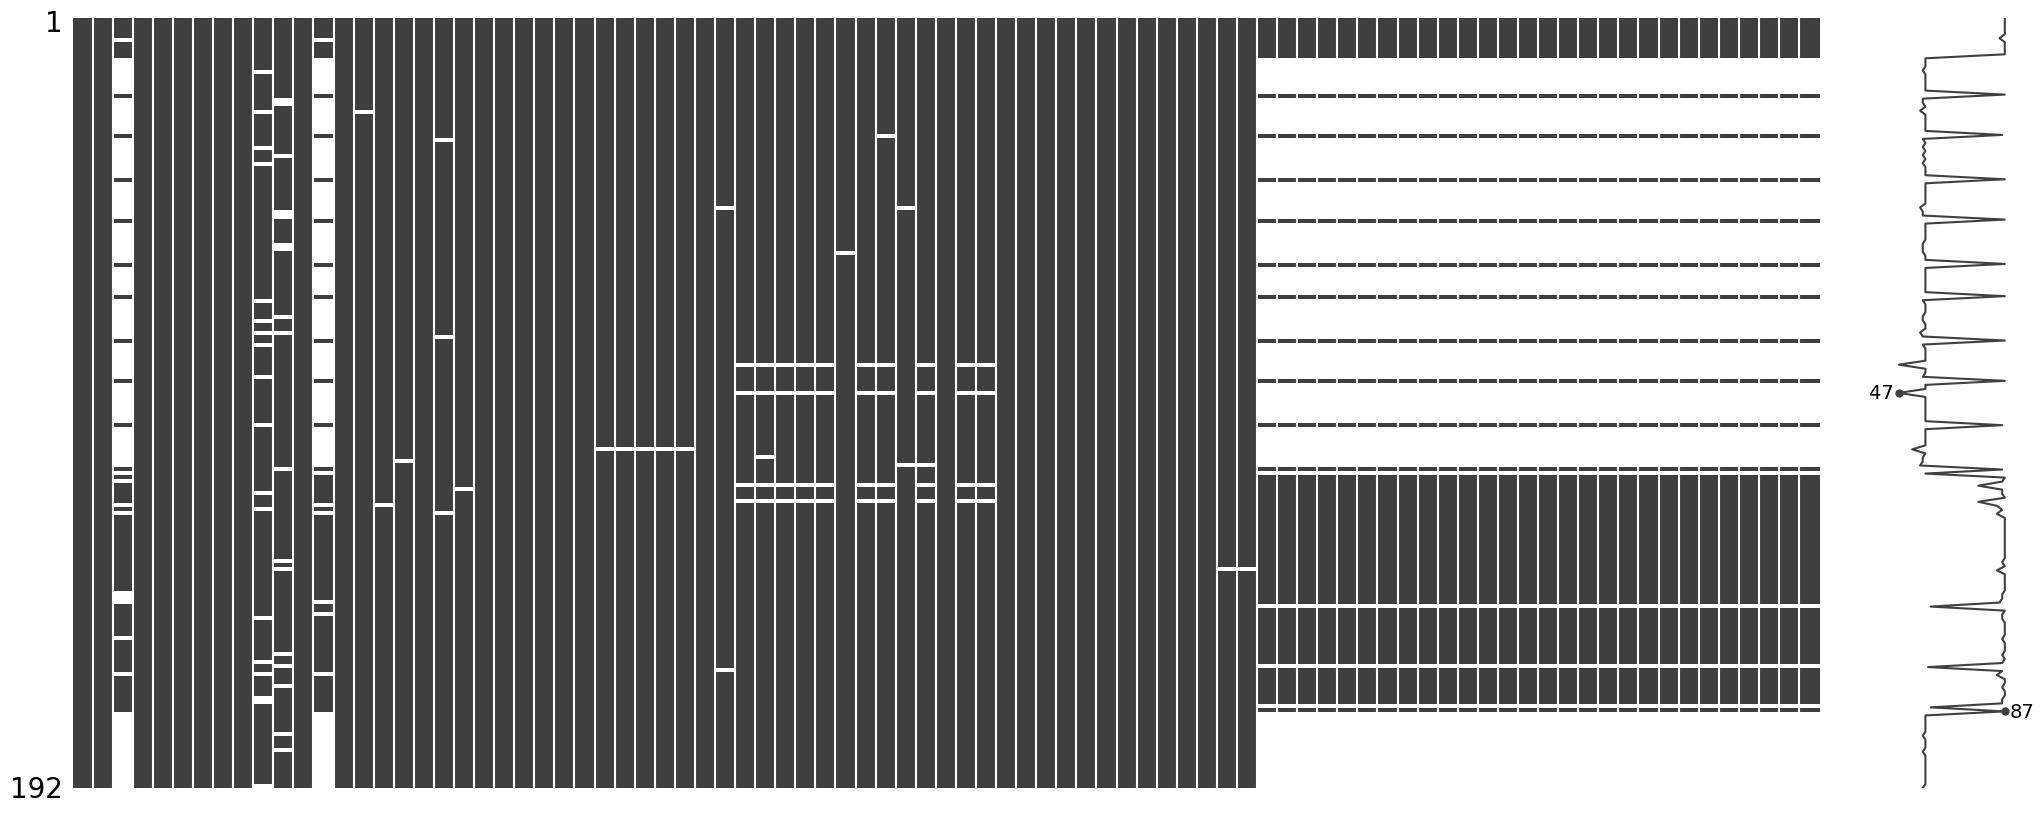

In [4]:
import missingno as msno

msno.matrix(df)

# 3. Understanding Variable Types
- Categorical variables: e.g., sex, education, learning_deficits, smoking_status

- Ordinal variables: e.g., education, ibuprofen_intake

- Binary variables: e.g., second_phase, drugs, hypertension

- Continuous variables: e.g., age, BMI, psychometric scores (BDI, SES, etc.)

Set categorical types for efficient analysis:

In [5]:
categorical_cols = [
    'APOE_haplotype','sex', 'education', 'learning_deficits', 'allergies', 'drugs', 'ibuprofen_intake', 'thyroid_diseases', 'hypertension','diabetes',
      'other_diseases','smoking_status', 'coffee_status', 'dementia_history_parents'
    ]

df[categorical_cols] = df[categorical_cols].astype('category')

# 4. Univariate Analysis
For Categorical Variables: Lets investigate the distribution of the data

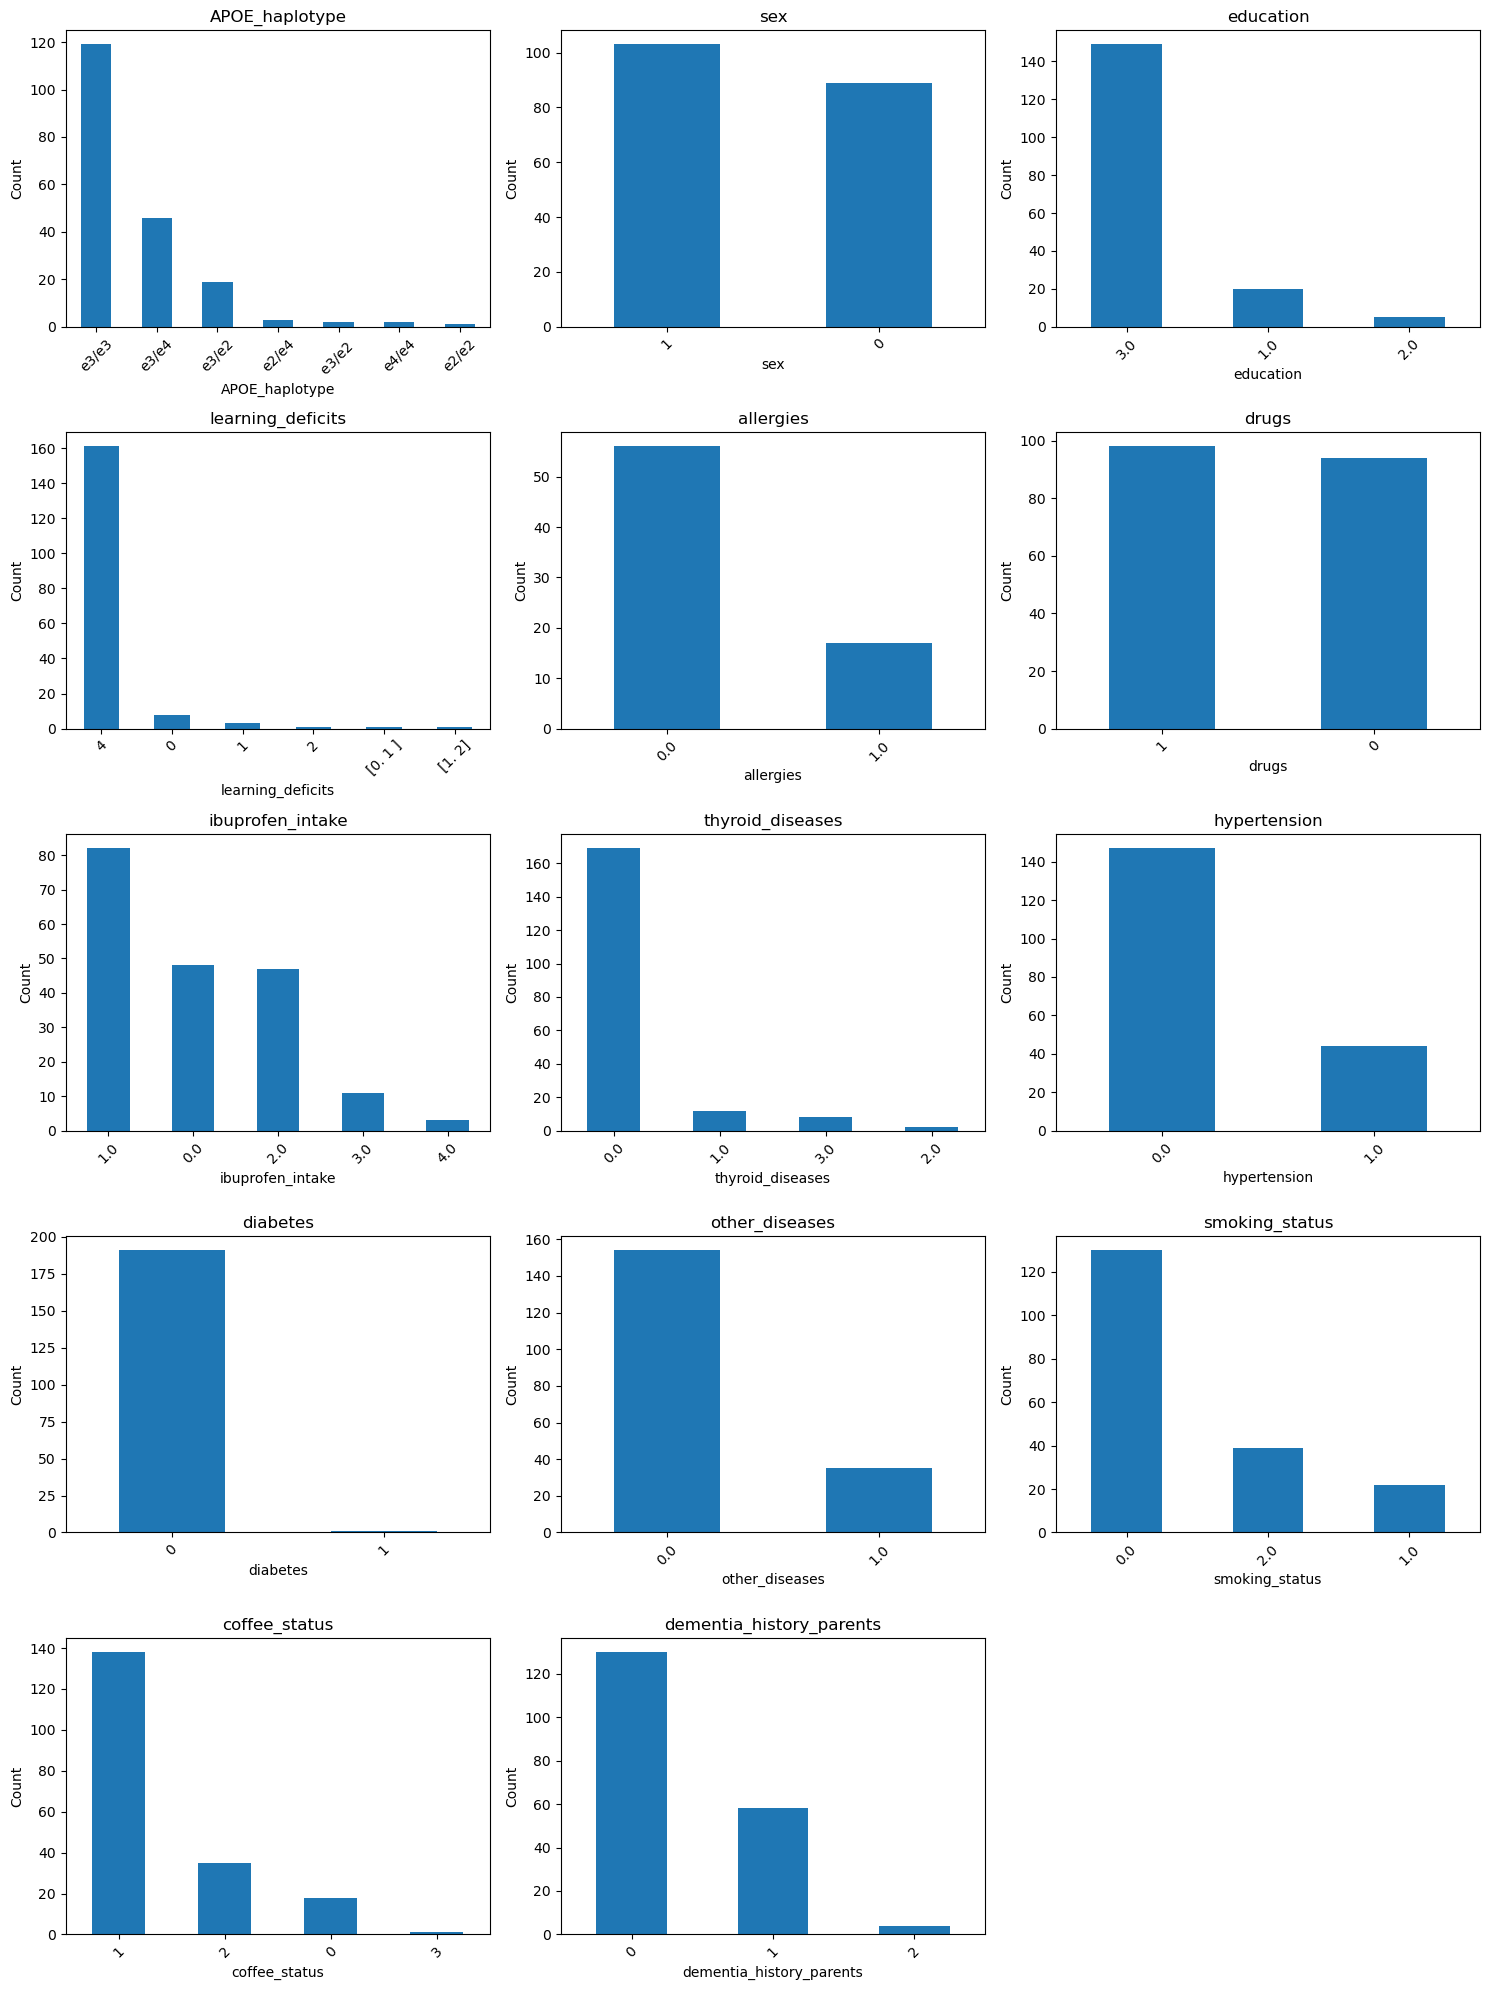

In [6]:

# Layout settings
n_cols = 3  # number of subplots per row
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols  # compute rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

# Plot each categorical column
for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Remove any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [7]:
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

For Continuous Variables:

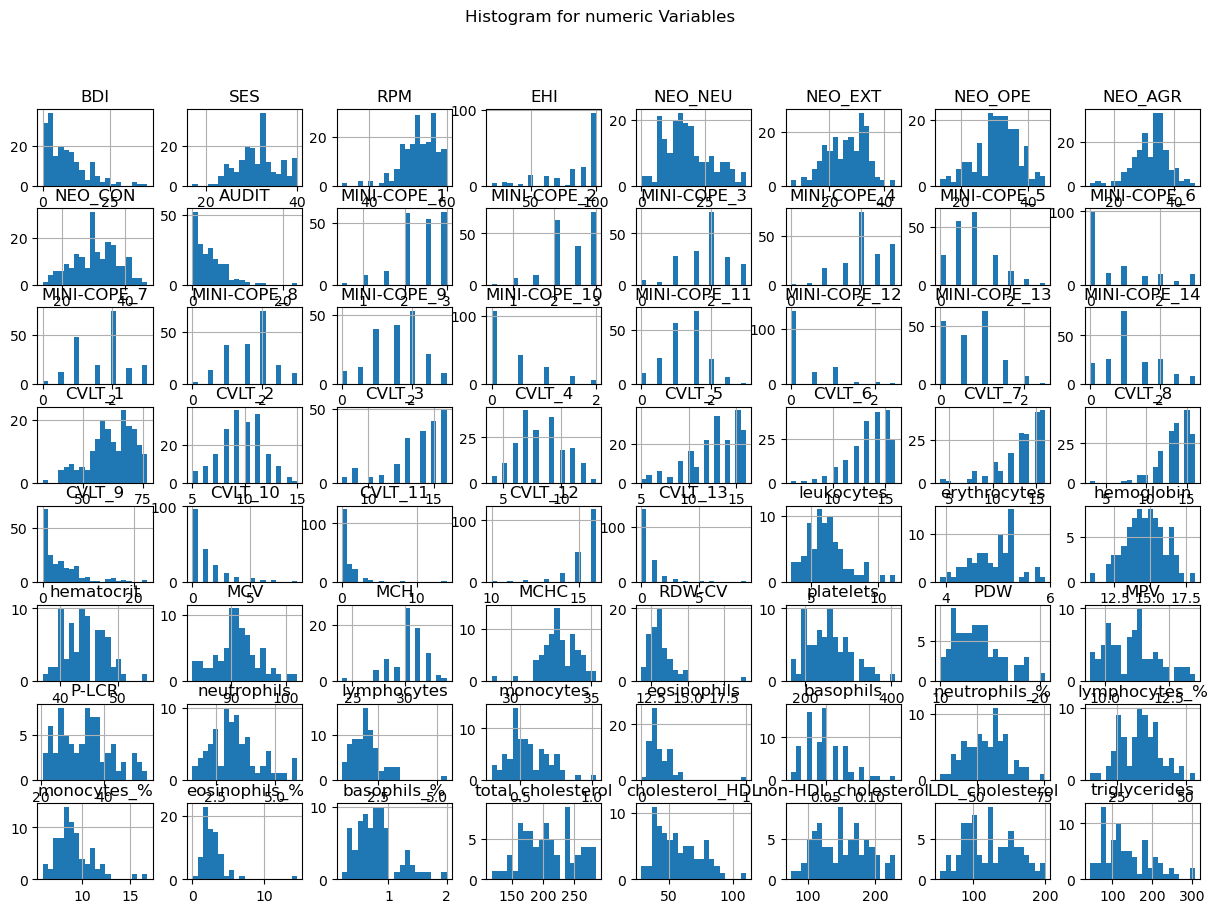

In [8]:
numerical_cols = ['BDI', 'SES', 'RPM', 'EHI', 'NEO_NEU', 'NEO_EXT', 'NEO_OPE', 'NEO_AGR',
                'NEO_CON', 'AUDIT', 'MINI-COPE_1', 'MINI-COPE_2', 'MINI-COPE_3', 'MINI-COPE_4',
                'MINI-COPE_5', 'MINI-COPE_6', 'MINI-COPE_7', 'MINI-COPE_8', 'MINI-COPE_9',
                  'MINI-COPE_10', 'MINI-COPE_11', 'MINI-COPE_12', 'MINI-COPE_13', 'MINI-COPE_14',
                    'CVLT_1', 'CVLT_2', 'CVLT_3', 'CVLT_4', 'CVLT_5', 'CVLT_6', 'CVLT_7', 'CVLT_8',
                      'CVLT_9', 'CVLT_10', 'CVLT_11', 'CVLT_12', 'CVLT_13', 'leukocytes', 'erythrocytes',
                        'hemoglobin', 'hematocrit', 'MCV', 'MCH', 'MCHC', 'RDW-CV', 'platelets', 'PDW',
                          'MPV', 'P-LCR', 'neutrophils', 'lymphocytes', 'monocytes', 'eosinophils', 'basophils',
                            'neutrophils_%', 'lymphocytes_%', 'monocytes_%', 'eosinophils_%', 'basophils_%',
                              'total_cholesterol', 'cholesterol_HDL', 'non-HDL_cholesterol', 'LDL_cholesterol',
                                'triglycerides']


df[numerical_cols].hist(bins=20, figsize=(15,10))
plt.suptitle("Histogram for numeric Variables")
plt.show()

5. Bivariate Analysis
Categorical vs. Continuous:


In [9]:
def plot_psyc_scores(groupby):
    pyschometric = ['BDI', 'SES', 'RPM', 'EHI']

    figs, axes = plt.subplots(2,2, sharey=False)
    axes = axes.flatten() 

    for i, test in enumerate(pyschometric):
        sns.boxplot(data=df, x=groupby, y=test, ax=axes[i])

    plt.tight_layout()
    plt.show()



# for cat in categorical_cols: 
#     plot_psyc_scores(cat)
#     print(df[cat].value_counts())

Continuous vs. Continuous:

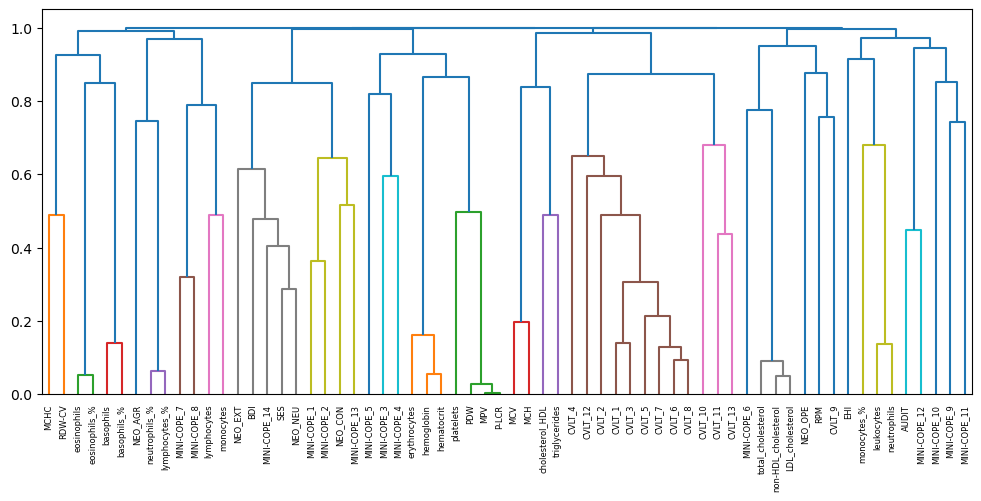

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

df_numeric = df[numerical_cols]

correlation_matrix = df_numeric.corr()

#create dendrogram
plt.figure(figsize=(12,5))
dissimilarity = 1 - abs(correlation_matrix)
Z = linkage(squareform(dissimilarity), 'complete')

dendrogram(Z, labels=df_numeric.columns, orientation='top', 
           leaf_rotation=90);


[ 5  5 11 13  5  5 11  3  5 14  5  5  6  6  6 10  4  4 15 15 15 14  5  5
  9  9  9  9  9  9  9  9 11  9  9  9  9 12  7  7  7  8  8  1  1  7  7  7
  7 12  4  4  2  2  3  3 12  2  2 10  8 10 10  8]


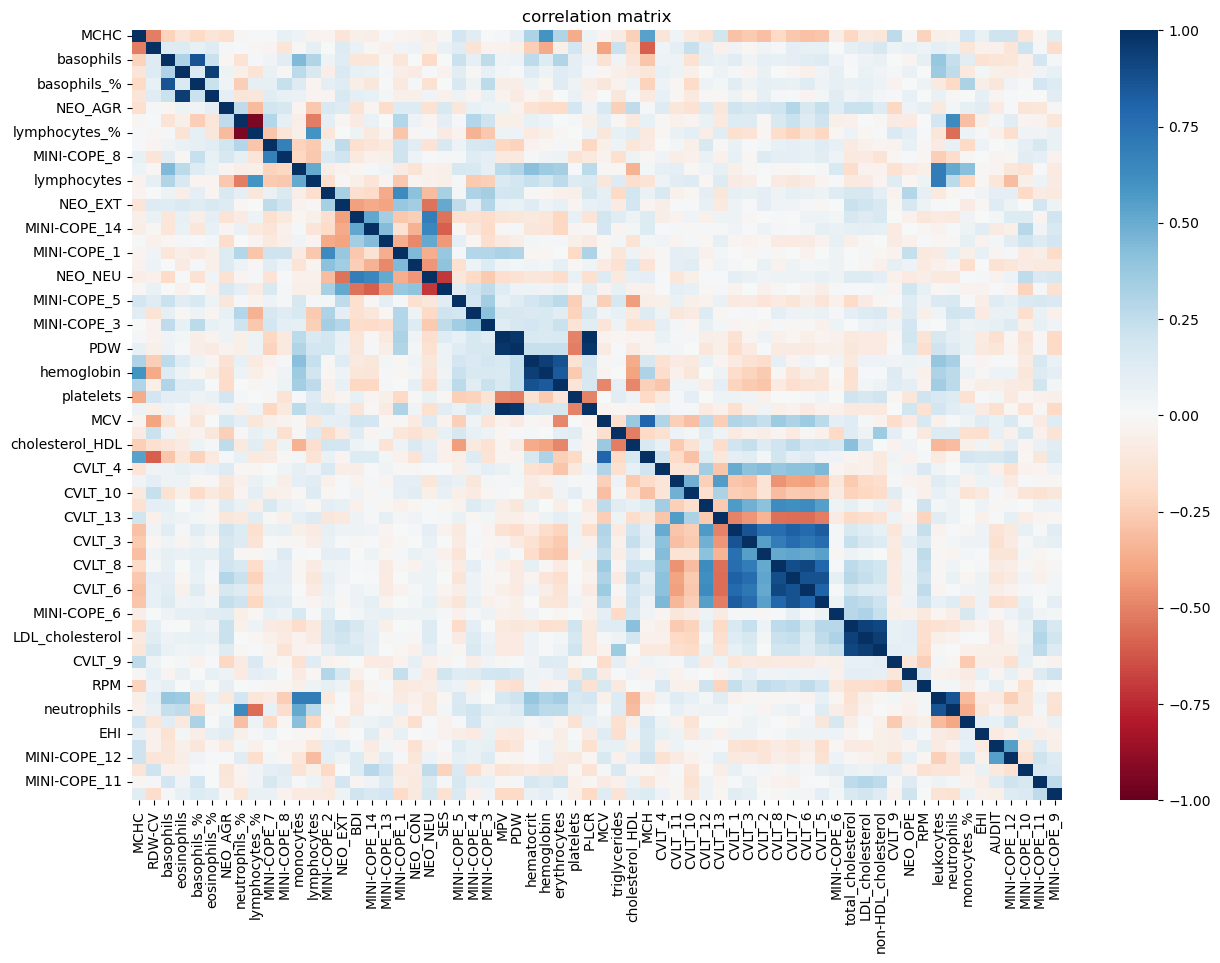

In [11]:
import numpy as np

#get cluster labels
threshold = 0.9
labels = fcluster(Z, threshold, criterion="distance")
print(labels)

#sort labels
labels_order = np.argsort(labels)

#rebuild dataframe in labels order
for idx, i in enumerate(df_numeric.columns[labels_order]):
    if idx == 0:
        clustered = pd.DataFrame(df_numeric[i])
    else:
        df_to_append = pd.DataFrame(df_numeric[i])
        clustered = pd.concat([clustered, df_to_append], axis=1)

#create correlation matrix
clustered_corr = clustered.corr()

#plot
plt.figure(figsize=(15,10))
sns.heatmap(round(clustered_corr,2),cmap='RdBu', annot=False, 
            annot_kws={"size": 7}, vmin=-1, vmax=1)
plt.title("correlation matrix")
plt.show()

Does dementia family history correlate with high BDI scores?



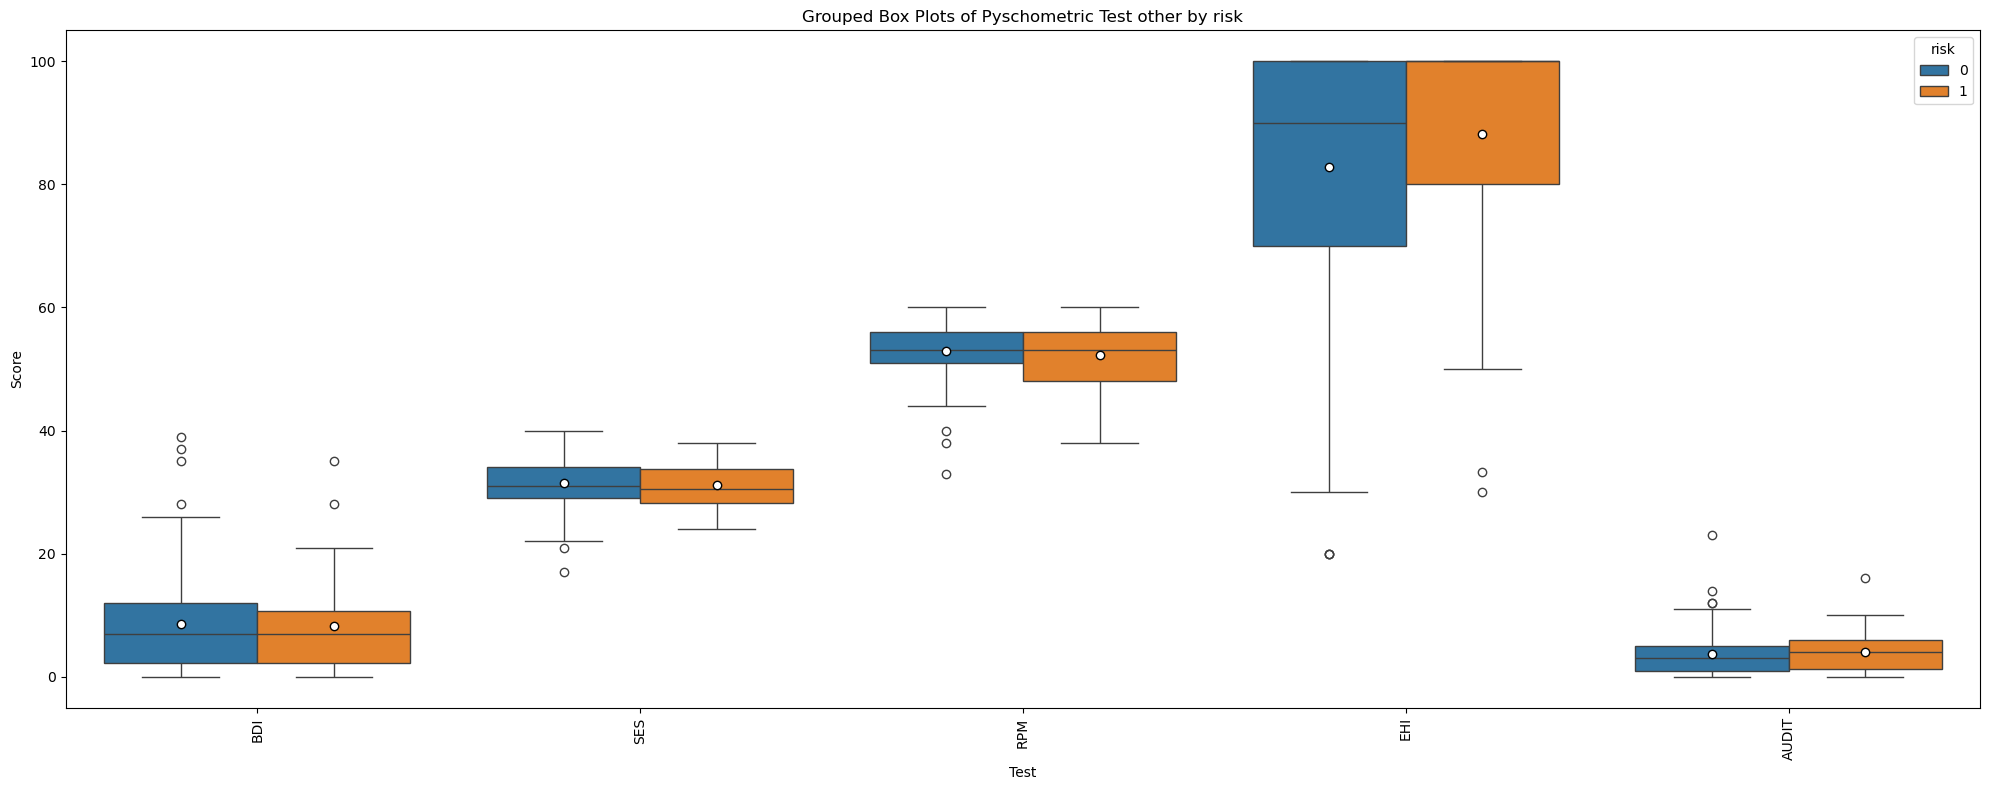

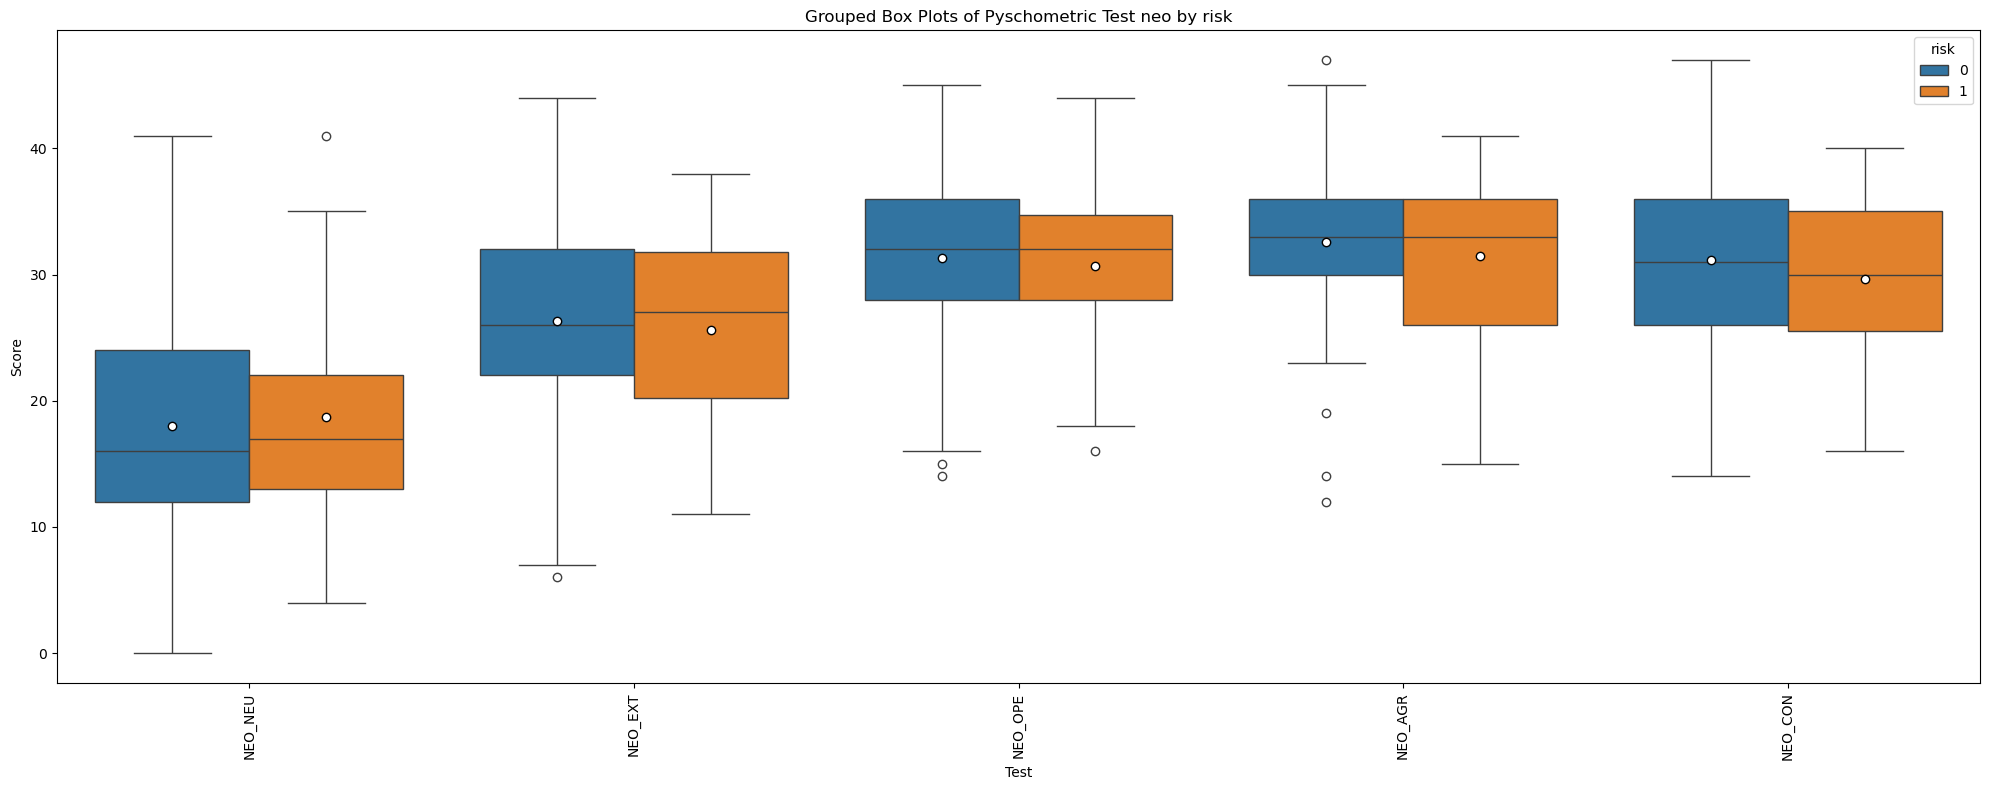

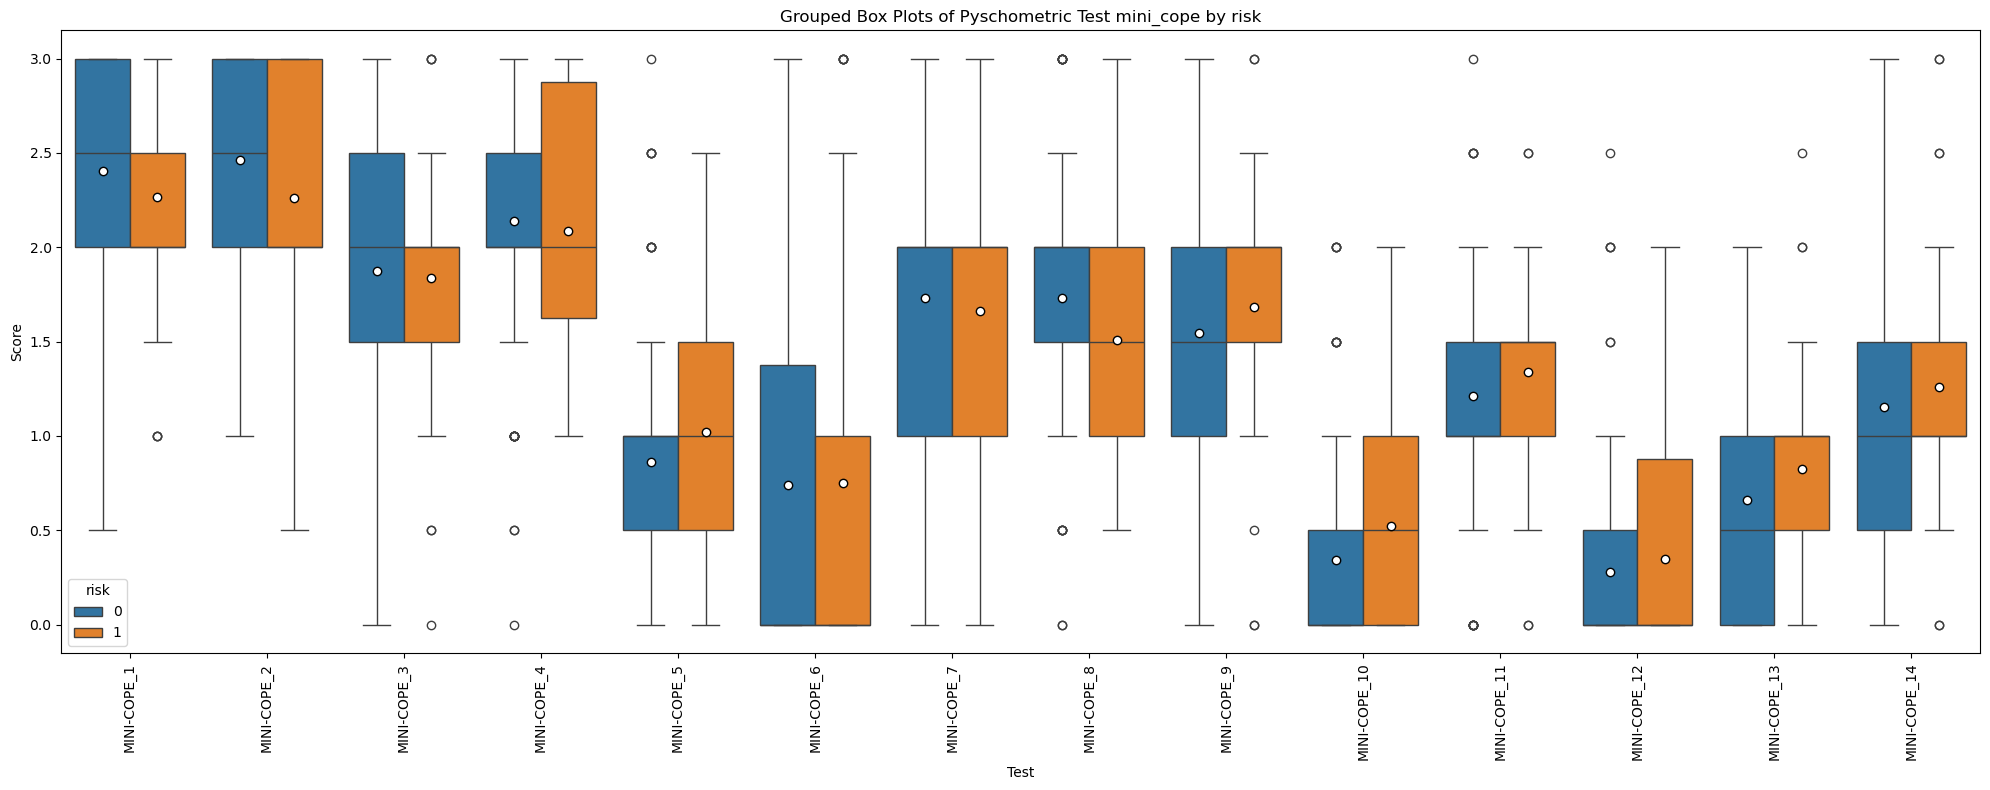

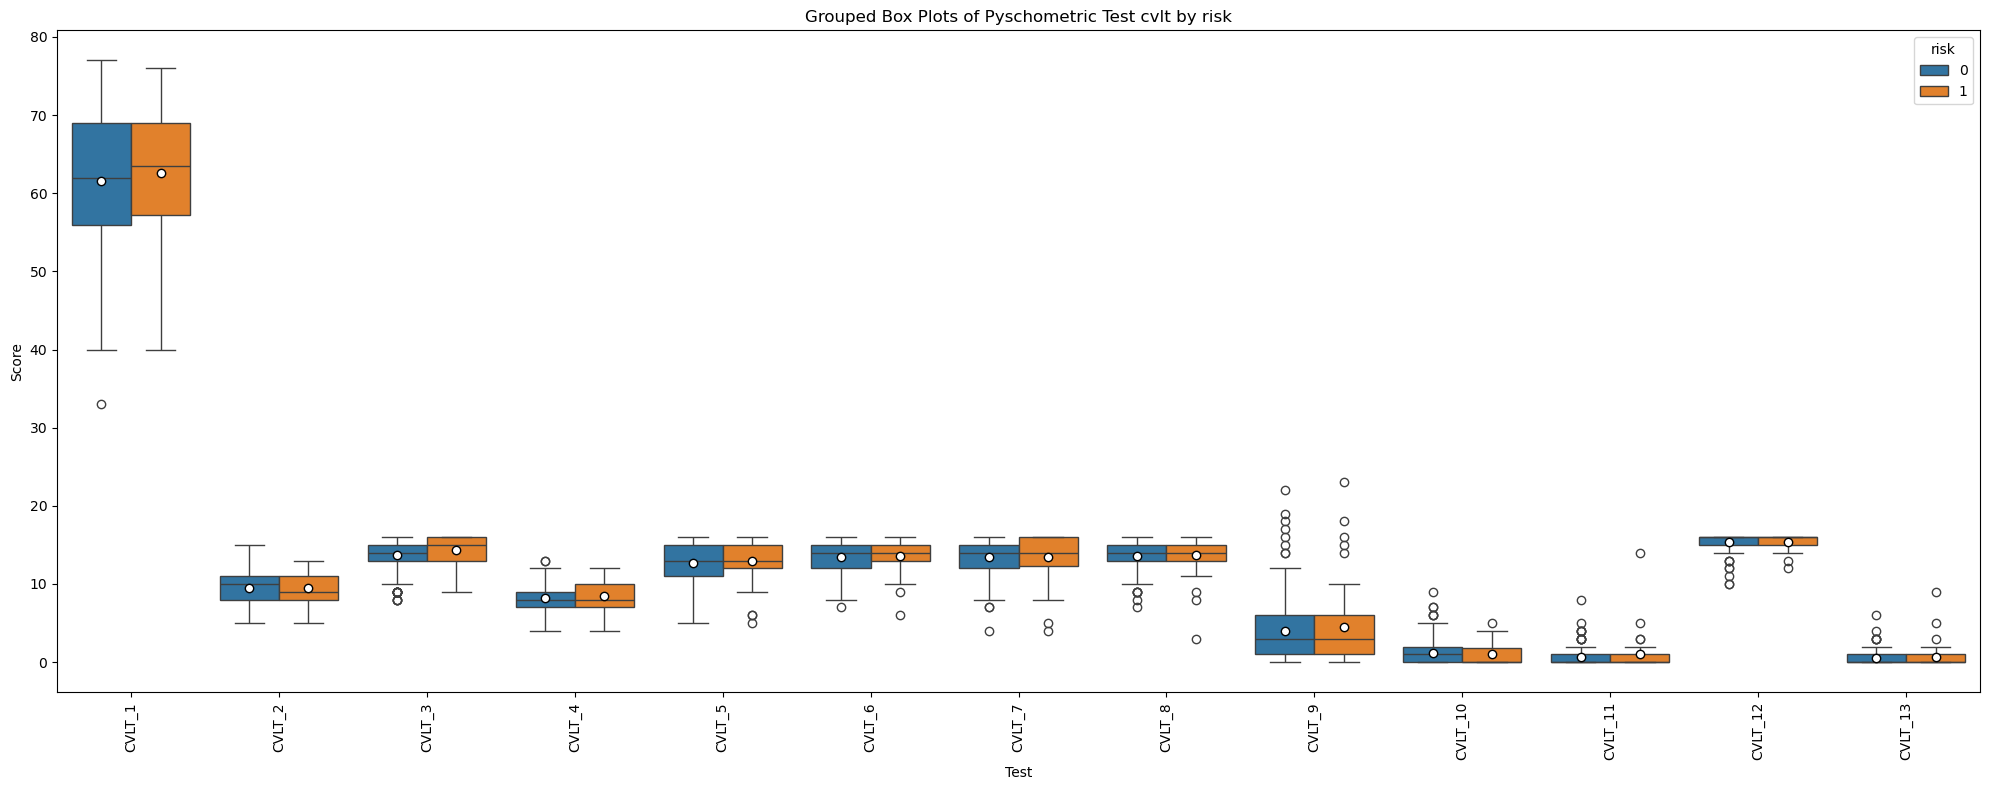

In [12]:
def plot_cog_scores(groupby):

  all_test = {
      "other" : ['BDI', 'SES', 'RPM', 'EHI',  'AUDIT'],
      "neo" : ['NEO_NEU', 'NEO_EXT', 'NEO_OPE', 'NEO_AGR','NEO_CON'],
      "mini_cope" : ['MINI-COPE_1', 'MINI-COPE_2', 'MINI-COPE_3', 'MINI-COPE_4',
                    'MINI-COPE_5', 'MINI-COPE_6', 'MINI-COPE_7', 'MINI-COPE_8',
                      'MINI-COPE_9','MINI-COPE_10', 'MINI-COPE_11', 'MINI-COPE_12',
                        'MINI-COPE_13', 'MINI-COPE_14'],
      "cvlt" : ['CVLT_1', 'CVLT_2', 'CVLT_3', 'CVLT_4', 'CVLT_5', 'CVLT_6', 'CVLT_7', 'CVLT_8',
                        'CVLT_9', 'CVLT_10', 'CVLT_11', 'CVLT_12', 'CVLT_13']
  }

  for key, value in all_test.items():

      df_long = df.melt(id_vars=groupby, value_vars=value, var_name="Test", value_name="Score")
      
      plt.figure(figsize=(20,8))
      sns.boxplot(data=df_long, x="Test", y='Score', hue=groupby, showmeans=True,
                  meanprops={"marker":"o", "markerfacecolor":"white", 
                          "markeredgecolor":"black", "markersize":"6"})

      plt.xticks(rotation=90)
      plt.title(f'Grouped Box Plots of Pyschometric Test {key} by {groupby}')
      plt.tight_layout()
      plt.show()

at_risk_haplos = 'e3/e4, e2/e4, e4/e4'.split(',')

df['risk'] = np.where(df['APOE_haplotype'].isin(at_risk_haplos), 1, 0) 

plot_cog_scores("risk")

# for cat in categorical_cols:
#   plot_cog_scores(cat)

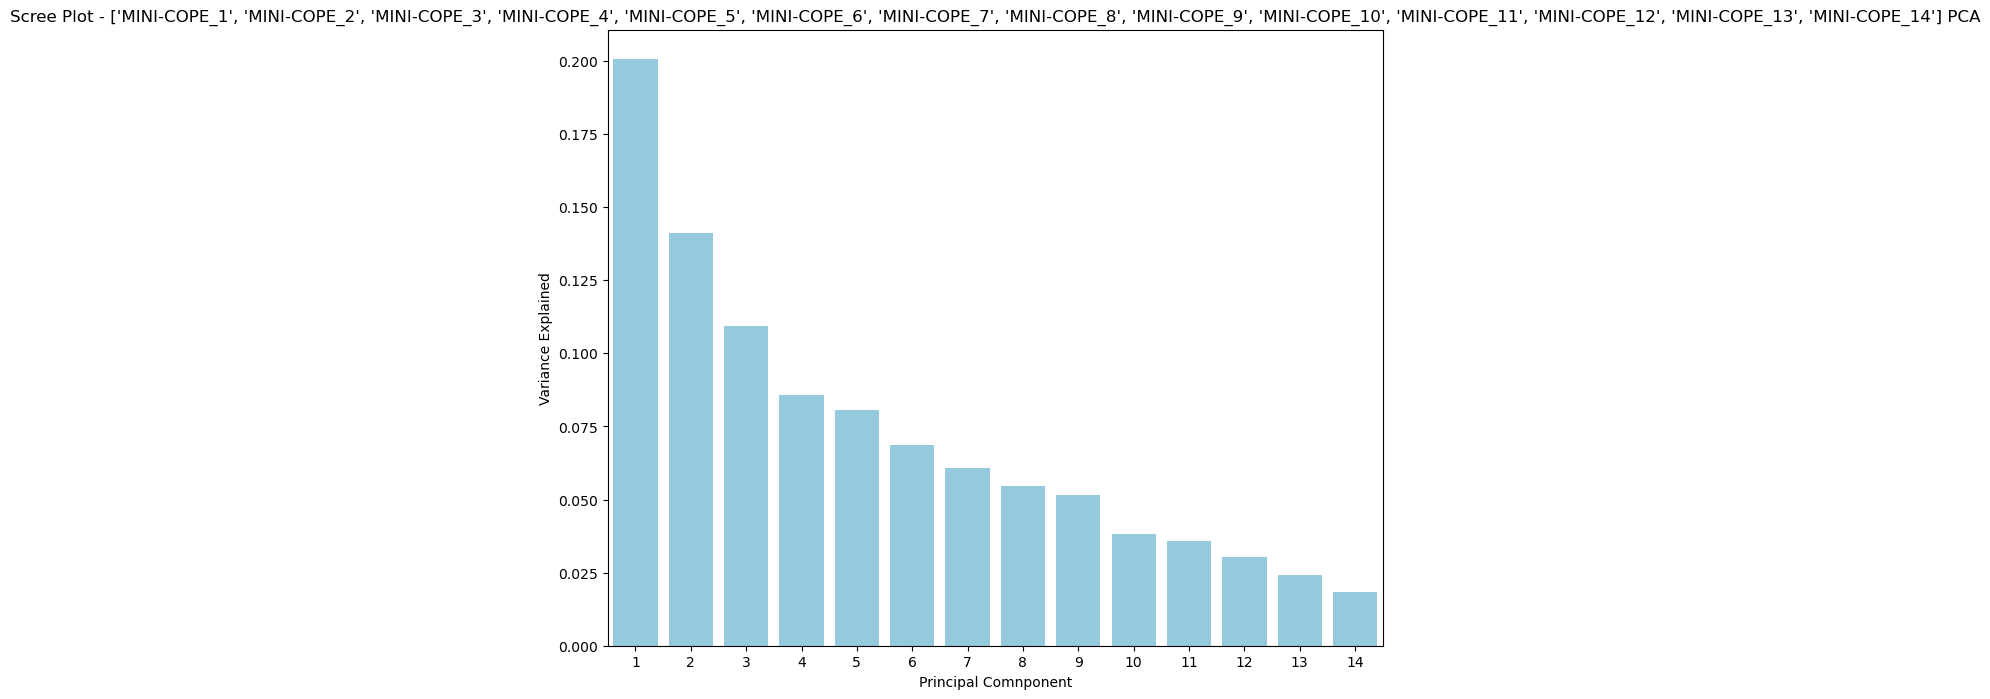

['MINI-COPE_1', 'MINI-COPE_2', 'MINI-COPE_3', 'MINI-COPE_4', 'MINI-COPE_5', 'MINI-COPE_6', 'MINI-COPE_7', 'MINI-COPE_8', 'MINI-COPE_9', 'MINI-COPE_10', 'MINI-COPE_11', 'MINI-COPE_12', 'MINI-COPE_13', 'MINI-COPE_14'] Loadings:
                    PC1       PC2       PC3       PC4       PC5       PC6  \
MINI-COPE_1   0.449713 -0.059054  0.040727  0.302052 -0.001216 -0.160865   
MINI-COPE_2   0.444567 -0.086360 -0.101236  0.287277  0.156058 -0.177688   
MINI-COPE_3   0.347660  0.228365 -0.300675  0.077466 -0.196635 -0.040322   
MINI-COPE_4   0.314146  0.152830 -0.231057  0.142087 -0.127716  0.529120   
MINI-COPE_5   0.082061  0.331457 -0.346190 -0.013935 -0.461490 -0.119614   
MINI-COPE_6   0.019239  0.118491  0.085550  0.461869  0.521786 -0.157517   
MINI-COPE_7   0.244909  0.376597  0.450716 -0.211661  0.039968  0.125257   
MINI-COPE_8   0.229382  0.316234  0.521301 -0.103461  0.019796  0.203698   
MINI-COPE_9  -0.149662  0.335108 -0.203809 -0.153417  0.121360 -0.337296   
MINI-COPE_10 

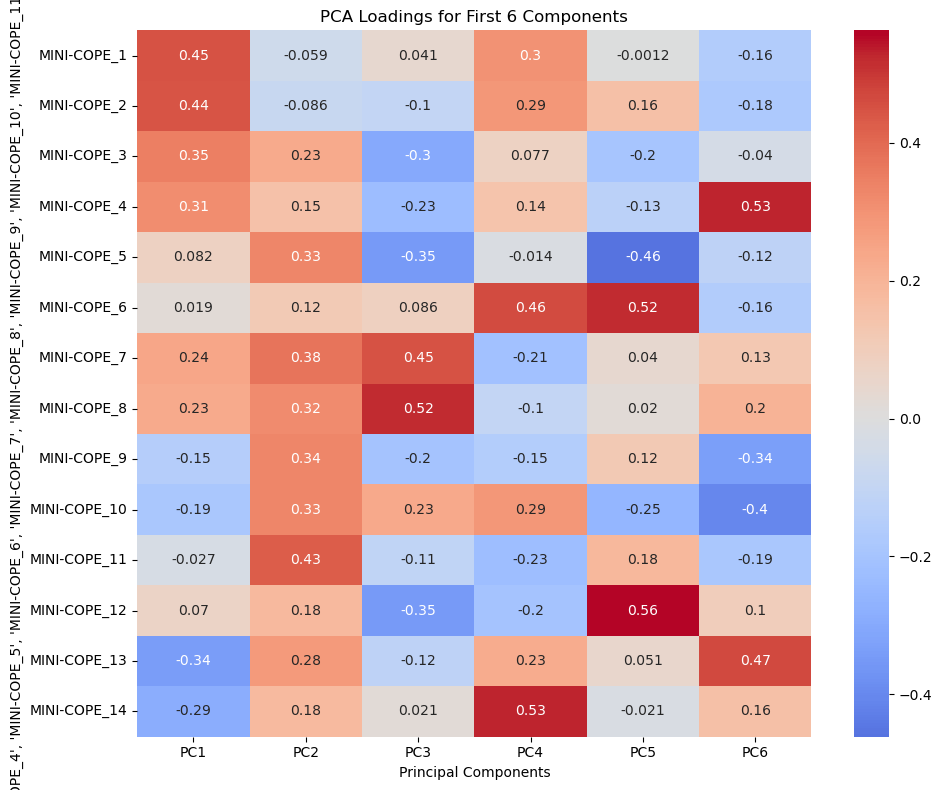

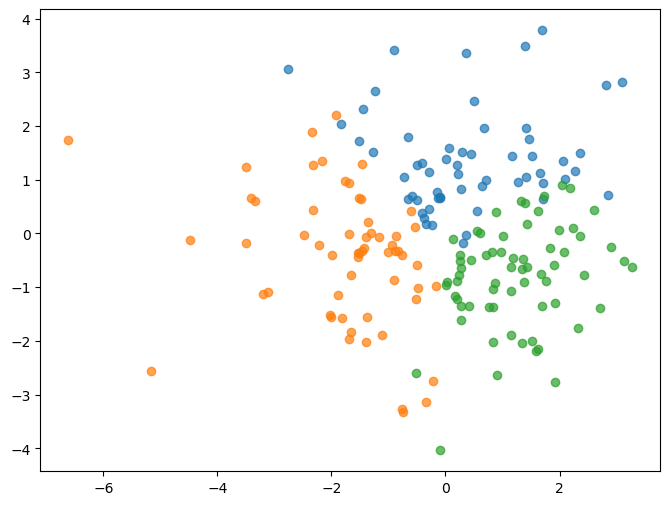

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering


mini_cope_cols = [
    'MINI-COPE_1', 'MINI-COPE_2', 'MINI-COPE_3', 'MINI-COPE_4',
                'MINI-COPE_5', 'MINI-COPE_6', 'MINI-COPE_7', 'MINI-COPE_8', 'MINI-COPE_9',
                  'MINI-COPE_10', 'MINI-COPE_11', 'MINI-COPE_12', 'MINI-COPE_13', 'MINI-COPE_14']
cvlt_cols = [
    'CVLT_1', 'CVLT_2', 'CVLT_3', 'CVLT_4', 'CVLT_5', 'CVLT_6', 'CVLT_7', 'CVLT_8',
    'CVLT_9', 'CVLT_10', 'CVLT_11', 'CVLT_12', 'CVLT_13']

def analyze_PCA(columns,cluster_size):
    X_df = df[columns].dropna()

    #standardize
    scalar = StandardScaler()
    X_scaled = scalar.fit_transform(X_df)

    #PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    #explained variance
    explained_variance = pca.explained_variance_ratio_

    #scree plot
    plt.figure(figsize=(10,8))
    sns.barplot(x=list(range(1,len(explained_variance) + 1)), y=explained_variance, color="skyblue")
    plt.title(f'Scree Plot - {columns} PCA')
    plt.xlabel('Principal Comnponent')
    plt.ylabel('Variance Explained')
    plt.show()

    # loadings
    loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(columns))], index=columns)
    print(f"{columns} Loadings:\n", loadings)

    plt.figure(figsize=(10, 8))
    sns.heatmap(loadings.iloc[:, :6], annot=True, cmap="coolwarm", center=0)
    plt.title("PCA Loadings for First 6 Components")
    plt.xlabel("Principal Components")
    plt.ylabel(f"{columns} Items")
    plt.tight_layout()
    plt.show()

    k = cluster_size  # Set the number of clusters you want
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_pca)

    # Plot the clusters in PCA space
    plt.figure(figsize=(8, 6))
    for cluster_id in range(k):
        plt.scatter(X_pca[clusters == cluster_id, 0],
                    X_pca[clusters == cluster_id, 1],
                    label=f'Cluster {cluster_id + 1}', alpha=0.7)

analyze_PCA(mini_cope_cols, 3)

Haplotype	Count	Notes
e3/e3	119	Baseline / most common
e3/e4	46	↑ Alzheimer’s risk
e3/e2	19	↓ Alzheimer’s risk
e2/e4	3	Complex effect
e4/e4	2	Highest genetic risk
e2/e2	1	Very protective
e3/e2 (dupe?)	2	Probably should be merged w/ e3/e2

In [30]:
import os
import json

labels_dict = df.set_index('participant_id')['risk'].to_dict()

# Define filename and path
filename = 'sub_risk_labels.json'
save_path = os.path.join('..', 'data', filename)

# Save to JSON file
with open(save_path, 'w') as f:
    json.dump(labels_dict, f, indent=4)